## COVID Drivers: Modeling

This notebook models

AGGRESSIVE_DRIVING ~
* POST_COVID
* CELL_PHONE
* IMPAIRED_DRIVER
* MATURE_DRIVER
* YOUNG_DRIVER
* FATIGUE_ASLEEP
* HIT_RUN
* UNLICENSED
* URBAN_RURALx

AGGRESSIVE_DRIVING ~
* POST_COVID
* IMPAIRED_DRIVER
* MATURE_DRIVER
* YOUNG_DRIVER
* FATIGUE_ASLEEP
* POST_COVID*IMPAIRED_DRIVER
* POST_COVID*MATURE_DRIVER
* POST_COVID*YOUNG_DRIVER
* POST_COVID*FATIGUE_ASLEEP

using logistic regression with Scikit Learn and Statsmodels

### Table of Contents
* [Read the Data](#read)</BR>
* [Preprocessing](#prep)</BR>
* [Logistic Regression with Cross Validation](#lgr-cv)</BR>
* [Logistic Regression with Statsmodels](#sm)</BR>
* [Logistic Regression with Cross Validation and Interaction](#lgr-cv-int)</BR>
* [Preprocessing with Interaction](#prep-int)</BR>
* [Logistic Regression with Statsmodels and Interaction](#sm-int)</BR>
* [Preprocessing for Robustness Testing](#prep-rob)</BR>
* [Robustness Testing with Statsmodels](#sm-rob)



Import packages

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import xgboost as xgb
from functools import reduce
#import prince

import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report, RocCurveDisplay

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
path_in = '/content/drive/MyDrive/Colab Notebooks/Case Studies in Data Science/data/ready/ready_data.csv'

### <a id='read'>Read the data</a>

Read dataset created in covid_drivers_05_Prep.ipynb

In [4]:
df_init = pd.read_csv(path_in, low_memory=False)

In [5]:
df_init['AGGRESSIVE_DRIVING'].sum()/df_init.shape[0]

np.float64(0.5598028680536025)

In [6]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [7]:
df_init.loc[df_init['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')]['AGGRESSIVE_DRIVING'].sum()/df_init.loc[df_init['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')].shape[0]

np.float64(0.5563778090234096)

In [8]:
df = df_init.copy()

In [9]:
df['POST_COVID_FATIGUE'] = df['POST_COVID']*df['FATIGUE_ASLEEP']

In [10]:
df['POST_COVID_YOUNG'] = df['POST_COVID']*df['YOUNG_DRIVER']

In [11]:
df['POST_COVID_PHONE'] = df['POST_COVID']*df['CELL_PHONE']

In [12]:
df['POST_COVID_IMPAIRED'] = df['POST_COVID']*df['IMPAIRED_DRIVER']

In [13]:
df.columns.tolist()

['CRN',
 'CRASH_DATE',
 'POST_COVID',
 'ALCOHOL_RELATED',
 'CELL_PHONE',
 'DISTRACTED',
 'DRINKING_DRIVER',
 'DRIVER_16YR',
 'DRIVER_17YR',
 'DRIVER_18YR',
 'DRIVER_19YR',
 'DRIVER_20YR',
 'DRIVER_50_64YR',
 'DRIVER_65_74YR',
 'DRIVER_75PLUS',
 'DRUGGED_DRIVER',
 'DRUG_RELATED',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'ILLEGAL_DRUG_RELATED',
 'IMPAIRED_DRIVER',
 'IMPAIRED_NONMOTORIST',
 'MARIJUANA_DRUGGED_DRIVER',
 'MARIJUANA_RELATED',
 'MATURE_DRIVER',
 'MC_DRINKING_DRIVER',
 'OPIOID_RELATED',
 'UNDERAGE_DRNK_DRV',
 'UNLICENSED',
 'YOUNG_DRIVER',
 'AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING',
 'COUNTYx',
 'URBAN_RURALx',
 'POST_COVID_FATIGUE',
 'POST_COVID_YOUNG',
 'POST_COVID_PHONE',
 'POST_COVID_IMPAIRED']

In [14]:
df['URBAN_RURALx'].unique()

array(['Rural', 'Urbanized'], dtype=object)

### <a id='prep'>Preprocessing</a>

In [15]:
X = df.loc[:,['POST_COVID',
 'CELL_PHONE',
 'IMPAIRED_DRIVER',
 'MATURE_DRIVER',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'UNLICENSED',
 'URBAN_RURALx']].copy()

In [16]:
y = df['AGGRESSIVE_DRIVING']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [18]:
categorical_cols = ['URBAN_RURALx']

In [19]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ], remainder='passthrough'
    )

In [21]:
add_constant_func = FunctionTransformer(sm.add_constant)

### <a id='lgr-cv'>Logistic Regression with Cross Validation</a>

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [23]:
lgr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logistic_regression', LogisticRegressionCV(random_state=42, cv=skf, solver='saga', l1_ratios=[0.1, 0.25, 0.5, 0.75, 0.9], max_iter=5000))
])

In [24]:
lgr_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1863: UserWarning: l1_ratios parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['URBAN_RURALx'])])),
                ('logistic_regression',
                 LogisticRegressionCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                      l1_ratios=[0.1, 0.25, 0.5, 0.75, 0.9],
                                      max_iter=5000, random_state=42,
                                      solver='saga'))])

In [25]:
# Extract the trained LogisticRegressionCV model
model = lgr_pipeline.named_steps['logistic_regression']

In [26]:
# Get Feature Names from Preprocessor - ColumnTransformer
feature_names = lgr_pipeline.named_steps['preprocessor'].get_feature_names_out()

In [27]:
# Get Coefficients (feature importance)
# model.coef_ shape is (1, n_features) for binary, or (n_classes, n_features)
# Using absolute value to get magnitude
importances = np.abs(model.coef_[0])

In [28]:
# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [29]:
print(feature_importance_df)

                       Feature  Importance
7    remainder__FATIGUE_ASLEEP    1.985435
3        remainder__CELL_PHONE    1.128570
4   remainder__IMPAIRED_DRIVER    0.527792
6      remainder__YOUNG_DRIVER    0.496979
5     remainder__MATURE_DRIVER    0.300931
8           remainder__HIT_RUN    0.176094
9        remainder__UNLICENSED    0.099017
0      cat__URBAN_RURALx_Rural    0.078224
1  cat__URBAN_RURALx_Urbanized    0.078208
2        remainder__POST_COVID    0.034167


In [30]:
feature_names

array(['cat__URBAN_RURALx_Rural', 'cat__URBAN_RURALx_Urbanized',
       'remainder__POST_COVID', 'remainder__CELL_PHONE',
       'remainder__IMPAIRED_DRIVER', 'remainder__MATURE_DRIVER',
       'remainder__YOUNG_DRIVER', 'remainder__FATIGUE_ASLEEP',
       'remainder__HIT_RUN', 'remainder__UNLICENSED'], dtype=object)

In [31]:
feature_names2 = []

for i, v in enumerate(feature_names):
  #print('Feature: %s' % (v))
  new = v.split('__')[1]
  if 'urban' in new.lower():
    new = new.split('_')[2].upper()
  feature_names2.append(new)

feature_names2


['RURAL',
 'URBANIZED',
 'POST_COVID',
 'CELL_PHONE',
 'IMPAIRED_DRIVER',
 'MATURE_DRIVER',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'UNLICENSED']

In [32]:
colors = ['teal', 'cadetblue', 'mediumaquamarine', 'seagreen', 'darkgreen', 'lightseagreen', 'skyblue', 'dodgerblue', 'royalblue', 'navy']

Feature: RURAL, Score: 0.07822
Feature: URBANIZED, Score: 0.07821
Feature: POST_COVID, Score: 0.03417
Feature: CELL_PHONE, Score: 1.12857
Feature: IMPAIRED_DRIVER, Score: 0.52779
Feature: MATURE_DRIVER, Score: 0.30093
Feature: YOUNG_DRIVER, Score: 0.49698
Feature: FATIGUE_ASLEEP, Score: 1.98544
Feature: HIT_RUN, Score: 0.17609
Feature: UNLICENSED, Score: 0.09902


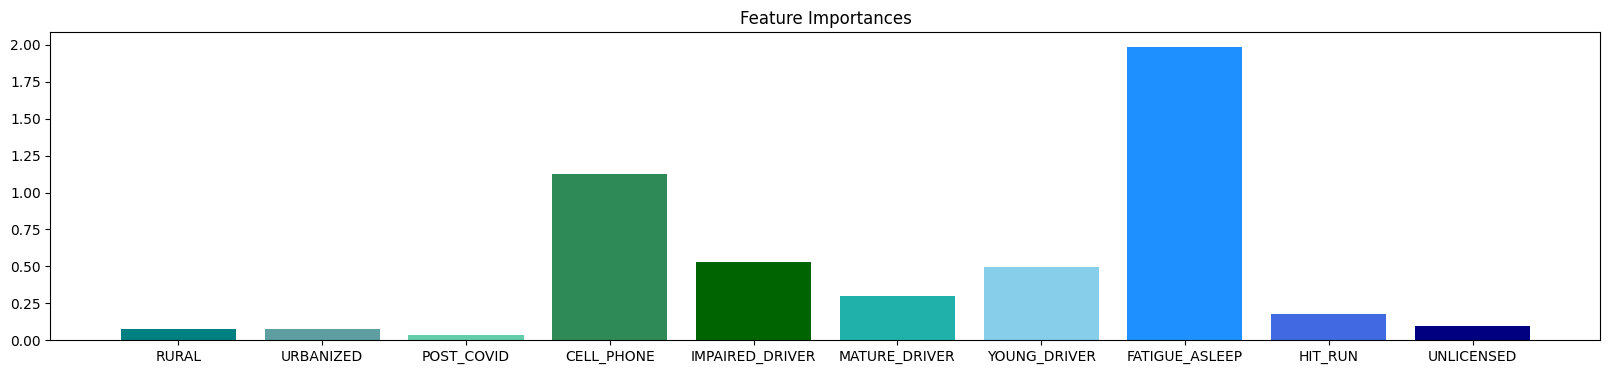

In [33]:
for i,v in enumerate(importances):
	#print('Feature: %0d, Score: %.5f' % (i,v))
  print('Feature: %s, Score: %.5f' % (feature_names2[i],v))
# plot feature importance
plt.bar(feature_names2, importances, color=colors)
fig = plt.gcf() # Get current figure
fig.set_size_inches(20, 4)
plt.title('Feature Importances')
plt.show()

Feature: 0, Score: 0.07822
Feature: 1, Score: 0.07821
Feature: 2, Score: 0.03417
Feature: 3, Score: 1.12857
Feature: 4, Score: 0.52779
Feature: 5, Score: 0.30093
Feature: 6, Score: 0.49698
Feature: 7, Score: 1.98544
Feature: 8, Score: 0.17609
Feature: 9, Score: 0.09902


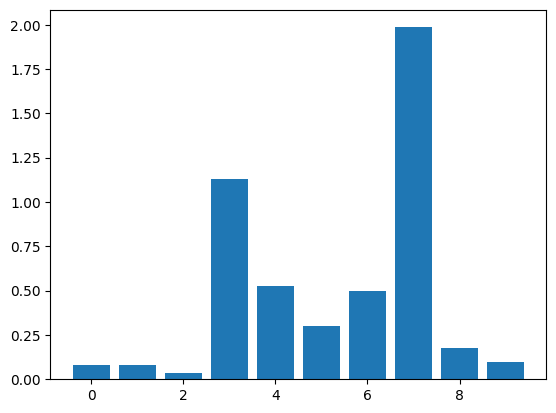

In [34]:
for i,v in enumerate(importances):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
plt.bar([x for x in range(len(importances))], importances)
plt.show()

In [35]:
y_pred = lgr_pipeline.predict(X_test)

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 59.14%


In [37]:
conf_matrix = confusion_matrix(y_test, y_pred)

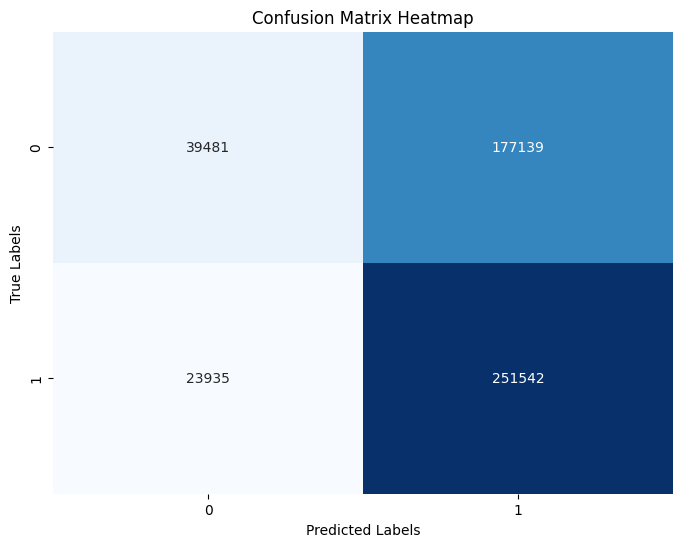

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [39]:
# Predicted probabilities for the class 1
y_pred_proba = lgr_pipeline.predict_proba(X_test)[:, 1]

In [40]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [41]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [42]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [43]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

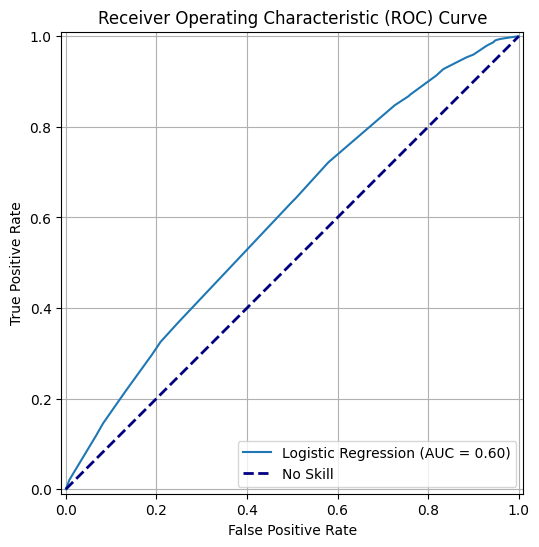

In [44]:
# Plot the ROC curve
# Using RocCurveDisplay.from_estimator is the recommended method in modern scikit-learn
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lgr_pipeline, X_test, y_test, ax=ax, name="Logistic Regression")

# Plot the "no skill" or chance level baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='No Skill')

# Customize the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic (ROC) Curve")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

In [45]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'LogisticRegressionCV'

In [46]:
aggdrv_lgr = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [47]:
aggdrv_lgr['LogisticRegressionCV'] = [round(x, 4) for x in aggdrv_lgr['LogisticRegressionCV']]

In [48]:
aggdrv_lgr

,Measure,LogisticRegressionCV
0,Accuracy,0.5914
1,Precision,0.5868
2,Recall,0.9131
3,F1 Score,0.7144
4,ROC AUC,0.6012


In [49]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.18      0.28    216620
           1       0.59      0.91      0.71    275477

    accuracy                           0.59    492097
   macro avg       0.60      0.55      0.50    492097
weighted avg       0.60      0.59      0.52    492097



### <a id='sm'>Logistic Regression with Statsmodels</a>

In [50]:
lgr_pipeline = Pipeline(steps=[
    ('add_constant', add_constant_func),
    ('preprocessor', preprocessor)
])

In [51]:
X_train_const = lgr_pipeline.named_steps['add_constant'].fit_transform(X_train)
X_test_const = lgr_pipeline.named_steps['add_constant'].transform(X_test)

In [52]:
X_train_trx = lgr_pipeline.named_steps['preprocessor'].fit_transform(X_train_const)
X_test_trx = lgr_pipeline.named_steps['preprocessor'].transform(X_test_const)

In [53]:
lgr_pipeline.named_steps['preprocessor'].get_feature_names_out()

array(['cat__URBAN_RURALx_Rural', 'cat__URBAN_RURALx_Urbanized',
       'remainder__const', 'remainder__POST_COVID',
       'remainder__CELL_PHONE', 'remainder__IMPAIRED_DRIVER',
       'remainder__MATURE_DRIVER', 'remainder__YOUNG_DRIVER',
       'remainder__FATIGUE_ASLEEP', 'remainder__HIT_RUN',
       'remainder__UNLICENSED'], dtype=object)

In [54]:
feature_names = lgr_pipeline.named_steps['preprocessor'].get_feature_names_out()
X_train_final = pd.DataFrame(X_train_trx, columns=feature_names)
X_test_final = pd.DataFrame(X_test_trx, columns=feature_names)

In [55]:
X_train_final['remainder__const'].unique()

array([1.])

In [56]:
model = sm.Logit(y_train.values, X_train_final)

In [57]:
result = model.fit(maxiter=1000)

         Current function value: 0.666000
         Iterations: 1000


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [58]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:              1968387
Model:                          Logit   Df Residuals:                  1968376
Method:                           MLE   Df Model:                           10
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.02912
Time:                        19:24:57   Log-Likelihood:            -1.3109e+06
converged:                      False   LL-Null:                   -1.3503e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
cat__URBAN_RURALx_Rural        -0.0128   7.81e+04  -1.64e-07      1.000   -1.53e+05    1.53e+05
cat__URBAN_RURALx_Urbanized     0.1436   7.81e+04   1.84e-06      1.000   -1.53e

### <a id='prep-int'>Preprocessing with Interaction</a>

In [60]:
X = df.loc[:,['POST_COVID',
 'IMPAIRED_DRIVER',
 'CELL_PHONE',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
  'POST_COVID_IMPAIRED',
  'POST_COVID_PHONE',
  'POST_COVID_YOUNG',
  'POST_COVID_FATIGUE',]].copy()

In [61]:
y = df['AGGRESSIVE_DRIVING']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [63]:
categorical_cols = ['URBAN_RURALx']

In [64]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [65]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ], remainder='passthrough'
    )

In [66]:
add_constant_func = FunctionTransformer(sm.add_constant)

### <a id='lgr-cv-int'>Logistic Regression with Cross Validation and Interaction</a>

In [67]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [68]:
lgr_pipeline = Pipeline(steps=[
    ('logistic_regression', LogisticRegressionCV(random_state=42, cv=skf, solver='saga', l1_ratios=[0.1, 0.25, 0.5, 0.75, 0.9], max_iter=5000))
])

In [69]:
lgr_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1863: UserWarning: l1_ratios parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Pipeline(steps=[('logistic_regression',
                 LogisticRegressionCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                      l1_ratios=[0.1, 0.25, 0.5, 0.75, 0.9],
                                      max_iter=5000, random_state=42,
                                      solver='saga'))])

In [70]:
# Extract the trained LogisticRegressionCV model
model = lgr_pipeline.named_steps['logistic_regression']

In [71]:
feature_names = lgr_pipeline.named_steps['logistic_regression'].feature_names_in_

In [72]:
# Get Coefficients (feature importance)
# model.coef_ shape is (1, n_features) for binary, or (n_classes, n_features)
# Using absolute value to get magnitude
importances = np.abs(model.coef_[0])

In [73]:
# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [74]:
print(feature_importance_df)

               Feature  Importance
4       FATIGUE_ASLEEP    1.641355
2           CELL_PHONE    0.831263
1      IMPAIRED_DRIVER    0.516690
3         YOUNG_DRIVER    0.444817
6     POST_COVID_PHONE    0.269200
5  POST_COVID_IMPAIRED    0.251859
8   POST_COVID_FATIGUE    0.205182
7     POST_COVID_YOUNG    0.069700
0           POST_COVID    0.007067


In [75]:
colors = ['teal', 'cadetblue', 'mediumaquamarine', 'seagreen', 'darkseagreen', 'lightseagreen', 'skyblue', 'dodgerblue', 'royalblue', 'navy']

Feature: POST_COVID, Score: 0.00707
Feature: IMPAIRED_DRIVER, Score: 0.51669
Feature: CELL_PHONE, Score: 0.83126
Feature: YOUNG_DRIVER, Score: 0.44482
Feature: FATIGUE_ASLEEP, Score: 1.64136
Feature: POST_COVID_IMPAIRED, Score: 0.25186
Feature: POST_COVID_PHONE, Score: 0.26920
Feature: POST_COVID_YOUNG, Score: 0.06970
Feature: POST_COVID_FATIGUE, Score: 0.20518


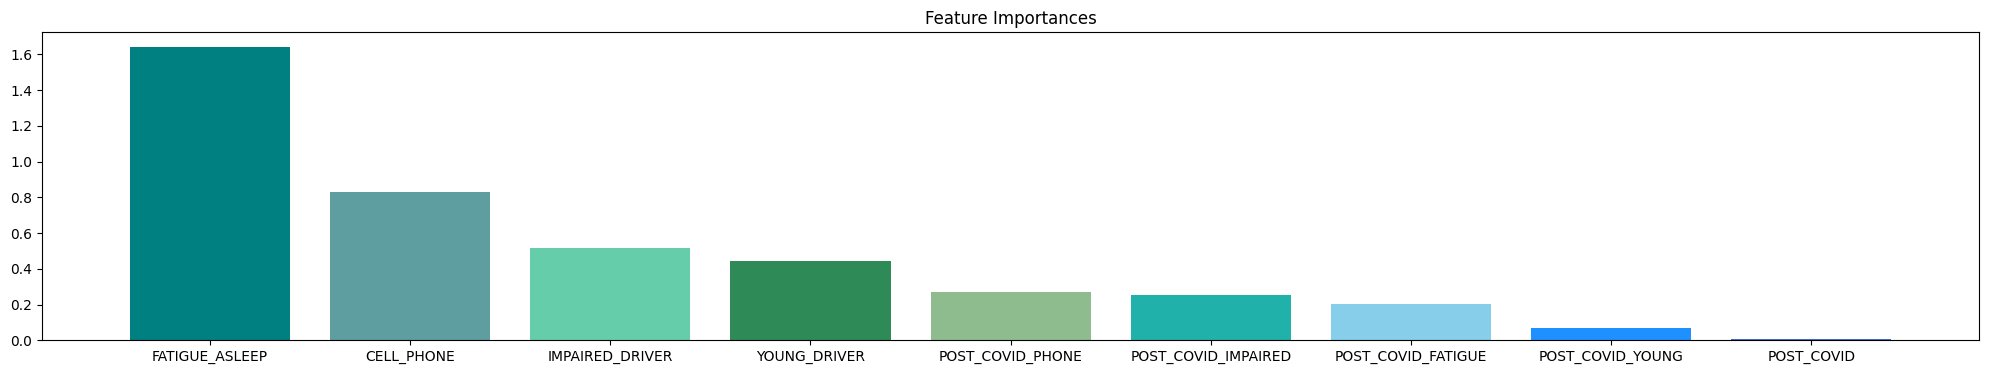

In [76]:
for i,v in enumerate(importances):
	#print('Feature: %0d, Score: %.5f' % (i,v))
  print('Feature: %s, Score: %.5f' % (feature_names[i],v))
# plot feature importance
#plt.bar(feature_names, importances, color=colors)
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors)
fig = plt.gcf() # Get current figure
fig.set_size_inches(25, 4)
plt.title('Feature Importances')
plt.show()

Feature: POST_COVID, Score: 0.00707
Feature: IMPAIRED_DRIVER, Score: 0.51669
Feature: CELL_PHONE, Score: 0.83126
Feature: YOUNG_DRIVER, Score: 0.44482
Feature: FATIGUE_ASLEEP, Score: 1.64136
Feature: POST_COVID_IMPAIRED, Score: 0.25186
Feature: POST_COVID_PHONE, Score: 0.26920
Feature: POST_COVID_YOUNG, Score: 0.06970
Feature: POST_COVID_FATIGUE, Score: 0.20518


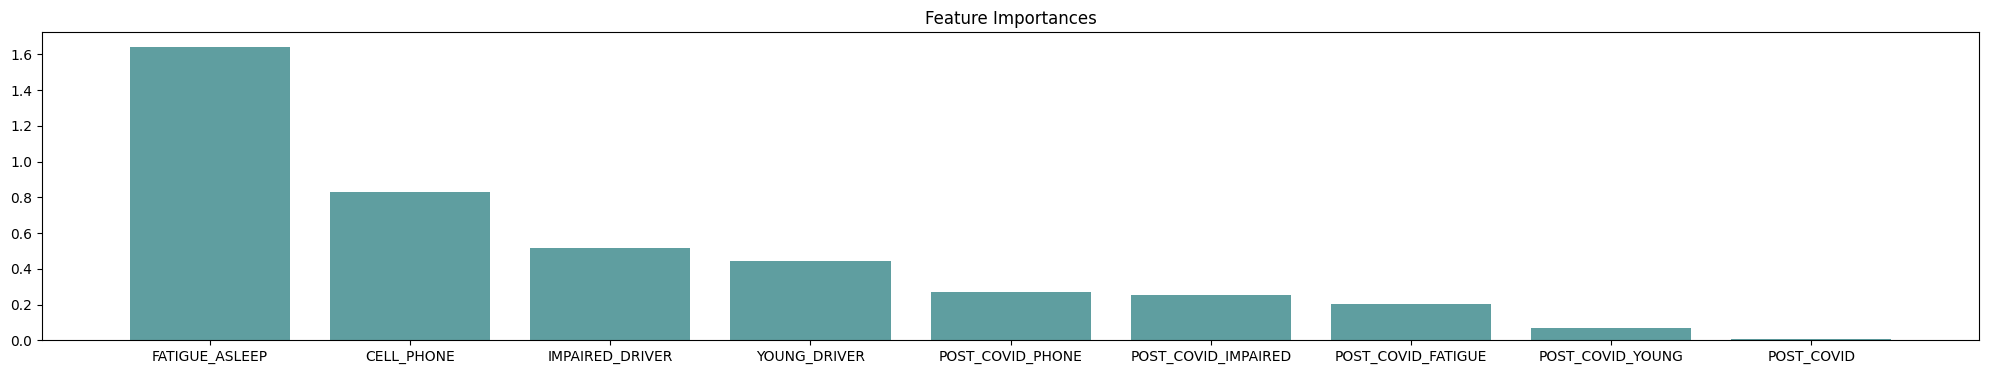

In [77]:
for i,v in enumerate(importances):
	#print('Feature: %0d, Score: %.5f' % (i,v))
  print('Feature: %s, Score: %.5f' % (feature_names[i],v))
# plot feature importance
#plt.bar(feature_names, importances, color='cadetblue')
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='cadetblue')
fig = plt.gcf() # Get current figure
fig.set_size_inches(25, 4)
plt.title('Feature Importances')
plt.show()

Feature: 0, Score: 0.00707
Feature: 1, Score: 0.51669
Feature: 2, Score: 0.83126
Feature: 3, Score: 0.44482
Feature: 4, Score: 1.64136
Feature: 5, Score: 0.25186
Feature: 6, Score: 0.26920
Feature: 7, Score: 0.06970
Feature: 8, Score: 0.20518


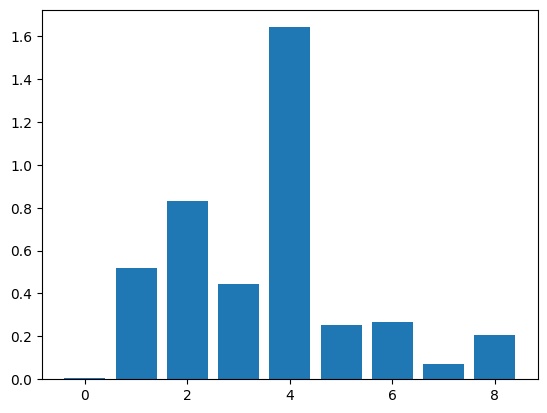

In [78]:
for i,v in enumerate(importances):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
plt.bar([x for x in range(len(importances))], importances)
plt.show()

In [79]:
y_pred = lgr_pipeline.predict(X_test)

In [80]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 59.25%


In [81]:
conf_matrix = confusion_matrix(y_test, y_pred)

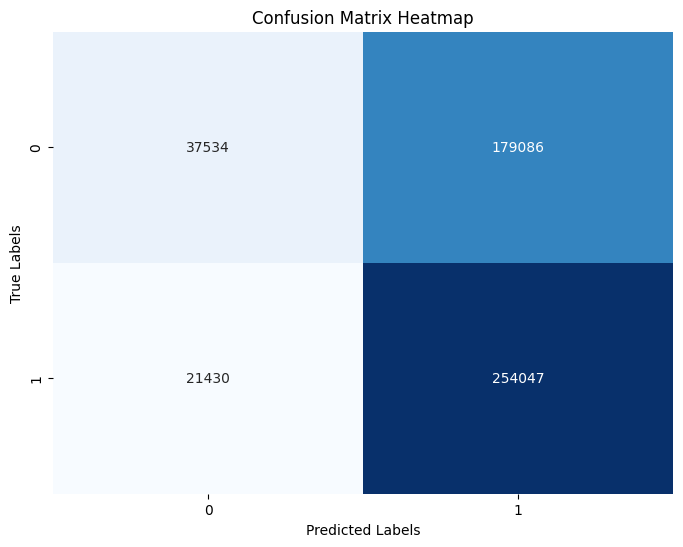

In [82]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [83]:
# Predicted probabilities for the class 1
y_pred_proba = lgr_pipeline.predict_proba(X_test)[:, 1]

In [84]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [85]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [86]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [87]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

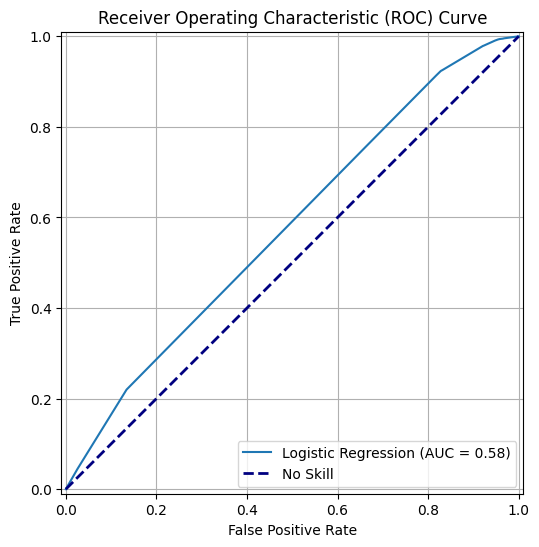

In [88]:
# Plot the ROC curve
# Using RocCurveDisplay.from_estimator is the recommended method in modern scikit-learn
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lgr_pipeline, X_test, y_test, ax=ax, name="Logistic Regression")

# Plot the "no skill" or chance level baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='No Skill')

# Customize the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic (ROC) Curve")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

In [89]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'LogisticRegressionCV'

In [90]:
aggdrv_lgr = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [91]:
aggdrv_lgr['LogisticRegressionCV'] = [round(x, 4) for x in aggdrv_lgr['LogisticRegressionCV']]

In [92]:
aggdrv_lgr

,Measure,LogisticRegressionCV
0,Accuracy,0.5925
1,Precision,0.5865
2,Recall,0.9222
3,F1 Score,0.7170
4,ROC AUC,0.5786


In [93]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.17      0.27    216620
           1       0.59      0.92      0.72    275477

    accuracy                           0.59    492097
   macro avg       0.61      0.55      0.49    492097
weighted avg       0.61      0.59      0.52    492097



### <a id='sm-int'>Logistic Regression with Statsmodels and Interaction</a>

In [94]:
X_train = sm.add_constant(X_train)

In [95]:
#X_train_sm = sm.add_constant(X_train_final)
model = sm.Logit(y_train.values, X_train)

In [96]:
result = model.fit()

Optimization terminated successfully.
         Current function value: 0.668267
         Iterations 6


In [97]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:              1968387
Model:                          Logit   Df Residuals:                  1968377
Method:                           MLE   Df Model:                            9
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.02582
Time:                        19:42:07   Log-Likelihood:            -1.3154e+06
converged:                       True   LL-Null:                   -1.3503e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.2583      0.002    132.445      0.000       0.254       0.262
POST_COVID             -0.0050      0.004     -1.209      0.226      -0.013       0.003
IMPAIRED_DRIVER 

In [98]:
importances = result.params.abs().sort_values(ascending=False)
print(importances.sort_values(ascending=False))

FATIGUE_ASLEEP         2.077946
CELL_PHONE             1.078199
IMPAIRED_DRIVER        0.527614
YOUNG_DRIVER           0.455133
POST_COVID_PHONE       0.306628
POST_COVID_IMPAIRED    0.280870
const                  0.258256
POST_COVID_YOUNG       0.066079
POST_COVID_FATIGUE     0.010536
POST_COVID             0.004972
dtype: float64


In [99]:
importances

,0
FATIGUE_ASLEEP,2.077946
CELL_PHONE,1.078199
IMPAIRED_DRIVER,0.527614
YOUNG_DRIVER,0.455133
POST_COVID_PHONE,0.306628
POST_COVID_IMPAIRED,0.280870
const,0.258256
POST_COVID_YOUNG,0.066079
POST_COVID_FATIGUE,0.010536
POST_COVID,0.004972


In [100]:
coeffs = result.params.abs().values
feature_names = result.params.index

In [101]:
# Create a clean DataFrame
summary_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeffs}).sort_values(by='Coefficient', ascending=False)
print(summary_df)

               Feature  Coefficient
5       FATIGUE_ASLEEP     2.077946
3           CELL_PHONE     1.078199
2      IMPAIRED_DRIVER     0.527614
4         YOUNG_DRIVER     0.455133
7     POST_COVID_PHONE     0.306628
6  POST_COVID_IMPAIRED     0.280870
0                const     0.258256
8     POST_COVID_YOUNG     0.066079
9   POST_COVID_FATIGUE     0.010536
1           POST_COVID     0.004972


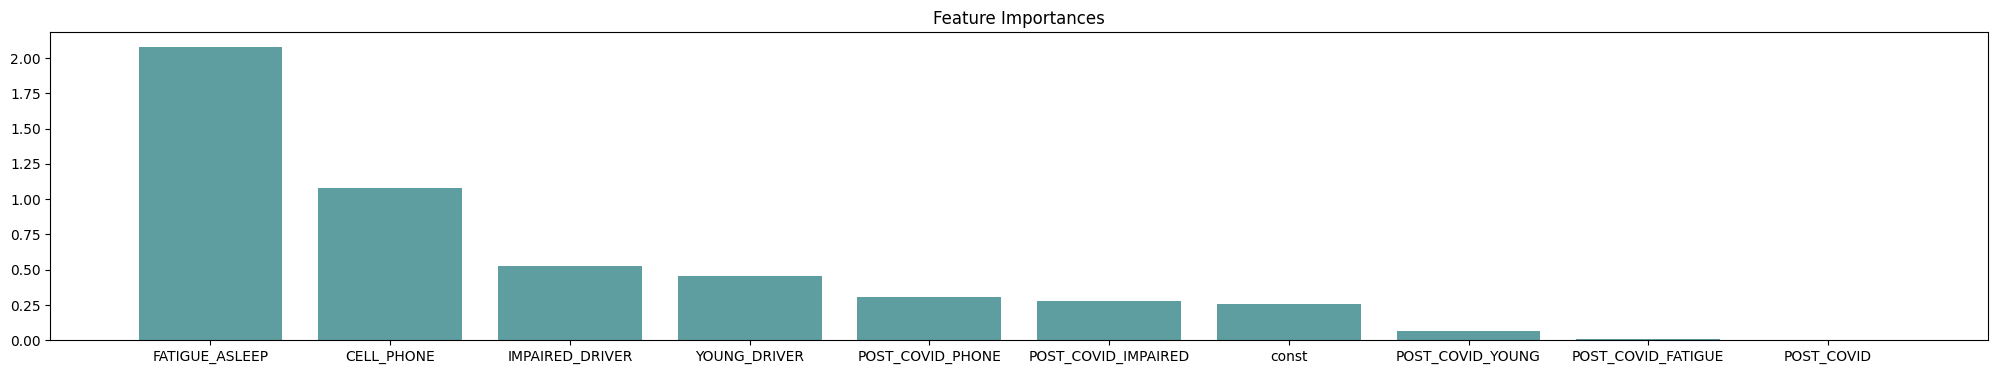

In [123]:
# plot feature importance
#plt.bar(feature_names, importances, color='cadetblue')
plt.bar(summary_df['Feature'], summary_df['Coefficient'], color='cadetblue')
fig = plt.gcf() # Get current figure
fig.set_size_inches(25, 4)
plt.title('Feature Importances')
plt.show()

### <a id='prep-rob'>Preprocessing for Robustness Testing</a>

In [103]:
#df1 = df.loc[df['URBAN_RURALx']=='Urbanized'].copy()
df1 = df.loc[(df['CRASH_DATE'] >= pd.to_datetime('2019-03-01', format='%Y-%m-%d')) & (df['CRASH_DATE'] < pd.to_datetime('2021-03-01', format='%Y-%m-%d'))].copy()

In [104]:
#df2 = df.loc[df['URBAN_RURALx']=='Rural'].copy()
df2 = df.loc[df['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')].copy()

In [105]:
#df.shape[0] == df1.shape[0] + df2.shape[0]

In [106]:
X1 = df1.loc[:,['POST_COVID',
 'IMPAIRED_DRIVER',
 'CELL_PHONE',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
  'POST_COVID_IMPAIRED',
  'POST_COVID_PHONE',
  'POST_COVID_YOUNG',
  'POST_COVID_FATIGUE']].copy()

In [107]:
X2 = df2.loc[:,['POST_COVID',
 'IMPAIRED_DRIVER',
 'CELL_PHONE',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
  'POST_COVID_IMPAIRED',
  'POST_COVID_PHONE',
  'POST_COVID_YOUNG',
  'POST_COVID_FATIGUE']].copy()

In [108]:
y1 = df1['AGGRESSIVE_DRIVING']
y2 = df2['AGGRESSIVE_DRIVING']

In [109]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, stratify=y1, random_state=42)

In [110]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=42)

In [111]:
add_constant_func = FunctionTransformer(sm.add_constant)

### <a id='sm-rob'>Robustness Testing with Statsmodels</a>

In [112]:
X1_train = sm.add_constant(X1_train)

In [113]:
#X_train_sm = sm.add_constant(X_train_final)
model = sm.Logit(y1_train.values, X1_train)

In [114]:
result1 = model.fit()

Optimization terminated successfully.
         Current function value: 0.670243
         Iterations 6


In [115]:
print(result1.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               180806
Model:                          Logit   Df Residuals:                   180796
Method:                           MLE   Df Model:                            9
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.02603
Time:                        19:42:11   Log-Likelihood:            -1.2118e+05
converged:                       True   LL-Null:                   -1.2442e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.2568      0.008     34.105      0.000       0.242       0.272
POST_COVID             -0.0587      0.011     -5.259      0.000      -0.081      -0.037
IMPAIRED_DRIVER 

In [116]:
importances1 = result1.params.abs().sort_values(ascending=False)
print(importances1.sort_values(ascending=False))

FATIGUE_ASLEEP         1.947719
CELL_PHONE             1.119949
IMPAIRED_DRIVER        0.733449
YOUNG_DRIVER           0.481416
const                  0.256830
POST_COVID             0.058721
POST_COVID_IMPAIRED    0.045150
POST_COVID_FATIGUE     0.042385
POST_COVID_PHONE       0.031981
POST_COVID_YOUNG       0.003688
dtype: float64


In [117]:
X2_train = sm.add_constant(X2_train)

In [118]:
#X_train_sm = sm.add_constant(X_train_final)
model = sm.Logit(y2_train.values, X2_train)

In [119]:
result2 = model.fit()

Optimization terminated successfully.
         Current function value: 0.666563
         Iterations 6


In [120]:
print(result2.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               940504
Model:                          Logit   Df Residuals:                   940494
Method:                           MLE   Df Model:                            9
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.02943
Time:                        19:42:19   Log-Likelihood:            -6.2691e+05
converged:                       True   LL-Null:                   -6.4592e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.2752      0.003     82.636      0.000       0.269       0.282
POST_COVID             -0.0237      0.005     -4.813      0.000      -0.033      -0.014
IMPAIRED_DRIVER 

In [121]:
importances2 = result2.params.abs().sort_values(ascending=False)
print(importances2.sort_values(ascending=False))

FATIGUE_ASLEEP         2.015361
CELL_PHONE             1.172605
IMPAIRED_DRIVER        0.690685
YOUNG_DRIVER           0.452147
const                  0.275170
POST_COVID_PHONE       0.211207
POST_COVID_IMPAIRED    0.109152
POST_COVID_YOUNG       0.070039
POST_COVID_FATIGUE     0.055407
POST_COVID             0.023671
dtype: float64


In [122]:
print(importances1.sort_values(ascending=False))

FATIGUE_ASLEEP         1.947719
CELL_PHONE             1.119949
IMPAIRED_DRIVER        0.733449
YOUNG_DRIVER           0.481416
const                  0.256830
POST_COVID             0.058721
POST_COVID_IMPAIRED    0.045150
POST_COVID_FATIGUE     0.042385
POST_COVID_PHONE       0.031981
POST_COVID_YOUNG       0.003688
dtype: float64
